# 01 — Residual Load and Day-Ahead Prices

Explore how residual load (demand minus wind and solar) drives day-ahead prices on the Polish power market.


## Load data


In [48]:
from clarwise import ClarwiseClient

client = ClarwiseClient()
client.list_datasets()

,table,description,date_column
0,generation_by_fuel_15min,"15-minute generation by fuel (solar, wind, fos...",date
1,prices_15min,15-minute RCE (volume weighted DA market price).,date
2,load_15min,"15-minute load forecast and actual, latest pub...",date


In [55]:
generation = client.get_dataset(
    "generation_by_fuel_15min",
    start_date="2020-01-01",
    end_date="2025-12-31",
    limit=300_000,
    columns=[
        "interval_start_utc",
        "biomass",
        "fossil_brown_coal_lignite",
        "fossil_coal_derived_gas",
        "fossil_gas",
        "fossil_hard_coal",
        "fossil_oil",
        "hydro_pumped_storage",
        "hydro_run_of_river_and_poundage",
        "hydro_water_reservoir",
        "other_renewable",
        "other",
    ],
)
generation.head()
print(generation.columns)
print(generation.shape)

Index(['interval_start_utc', 'biomass', 'fossil_brown_coal_lignite',
       'fossil_coal_derived_gas', 'fossil_gas', 'fossil_hard_coal',
       'fossil_oil', 'hydro_pumped_storage', 'hydro_run_of_river_and_poundage',
       'hydro_water_reservoir', 'other_renewable', 'other'],
      dtype='str')
(210304, 12)


In [56]:
prices = client.get_dataset(
    "prices_15min",
    start_date="2020-01-01",
    end_date="2025-12-31",
    limit=300_000,
)
print(prices.columns)
print(prices.shape)
prices.head()

Index(['interval_start_utc', 'interval_end_utc', 'interval_start_local',
       'interval_end_local', 'date', 'rce'],
      dtype='str')
(210396, 6)


,interval_start_utc,interval_end_utc,interval_start_local,interval_end_local,date,rce
0,2020-01-01T11:00:00,2020-01-01T11:15:00,2020-01-01T12:00:00,2020-01-01T12:15:00,2020-01-01,153.48
1,2020-01-01T14:30:00,2020-01-01T14:45:00,2020-01-01T15:30:00,2020-01-01T15:45:00,2020-01-01,154.52
2,2020-01-01T17:45:00,2020-01-01T18:00:00,2020-01-01T18:45:00,2020-01-01T19:00:00,2020-01-01,166.20
3,2020-01-01T02:00:00,2020-01-01T02:15:00,2020-01-01T03:00:00,2020-01-01T03:15:00,2020-01-01,111.83
4,2020-01-01T16:15:00,2020-01-01T16:30:00,2020-01-01T17:15:00,2020-01-01T17:30:00,2020-01-01,163.68


In [ ]:
# for d in (generation, prices):
#     d["interval_start_utc"] = pd.to_datetime(d["interval_start_utc"], utc=True)


# ts_local = generation["interval_start_utc"].dt.tz_convert("Europe/Warsaw")
# generation["year"] = ts_local.dt.year
# generation["month"] = ts_local.dt.month

# ts_local = prices["interval_start_utc"].dt.tz_convert("Europe/Warsaw")
# prices["year"] = ts_local.dt.year
# prices["month"] = ts_local.dt.month

# print(prices.groupby(["year", "month"]).size())

# print(generation.groupby(["year", "month"]).size())


year  month
2020  1        2976
      2        2784
      3        2968
      4        2880
      5        2976
               ... 
2025  8        2976
      9        2880
      10       2980
      11       2880
      12       2976
Length: 72, dtype: int64
year  month
2020  1        2976
      2        2784
      3        2972
      4        2880
      5        2976
               ... 
2025  8        2976
      9        2880
      10       2980
      11       2880
      12       2976
Length: 72, dtype: int64


## Build hourly merged dataset

Aggregate the 15-minute generation and price series to hourly resolution. Residual load is
computed directly from `generation_by_fuel_15min` as the sum of all dispatchable fuel
categories (biomass, fossil, hydro, other) — i.e., total generation minus solar and wind —
and converted to GW. Hour-of-day and month are taken in Europe/Warsaw local time.


In [58]:
# import calendar

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

for d in (generation, prices):
    d["interval_start_utc"] = pd.to_datetime(d["interval_start_utc"], utc=True)

dispatchable_cols = [
    "biomass",
    "fossil_brown_coal_lignite",
    "fossil_coal_derived_gas",
    "fossil_gas",
    "fossil_hard_coal",
    "fossil_oil",
    "hydro_pumped_storage",
    "hydro_run_of_river_and_poundage",
    "hydro_water_reservoir",
    "other_renewable",
    "other",
]
gen = generation.copy()
gen["residual_load_mw"] = gen[dispatchable_cols].fillna(0).sum(axis=1)

gen_h = (
    gen.set_index("interval_start_utc")[["residual_load_mw"]]
    .resample("1h")
    .mean()
    .reset_index()
)
prices_h = (
    prices.set_index("interval_start_utc")[["rce"]]
    .resample("1h")
    .mean()
    .reset_index()
)

df = gen_h.merge(prices_h, on="interval_start_utc").dropna(
    subset=["residual_load_mw", "rce"]
)
df["residual_load_gw"] = df["residual_load_mw"] / 1000.0

ts_local = df["interval_start_utc"].dt.tz_convert("Europe/Warsaw")
df["year"] = ts_local.dt.year
df["month"] = ts_local.dt.month
df["hour"] = ts_local.dt.hour
df["date_local"] = ts_local.dt.normalize().dt.tz_localize(None)
season_map = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn",
}
df["season"] = df["month"].map(season_map)

years_sorted = sorted(df["year"].unique())
print(f"Hourly observations: {len(df):,}")
print(f"Years available: {years_sorted}")
df.head()

Hourly observations: 52,571
Years available: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


,interval_start_utc,residual_load_mw,rce,residual_load_gw,year,month,hour,date_local,season
0,2019-12-31 23:00:00+00:00,11077.0,136.60,11.077,2020,1,0,2020-01-01,Winter
1,2020-01-01 00:00:00+00:00,10713.0,130.30,10.713,2020,1,1,2020-01-01,Winter
2,2020-01-01 01:00:00+00:00,10539.0,120.68,10.539,2020,1,2,2020-01-01,Winter
3,2020-01-01 02:00:00+00:00,10224.0,111.83,10.224,2020,1,3,2020-01-01,Winter
4,2020-01-01 03:00:00+00:00,10126.0,102.89,10.126,2020,1,4,2020-01-01,Winter


## LOWESS smoother

Thin wrapper around `statsmodels.nonparametric.smoothers_lowess.lowess`. Returns the
smoothed curve on a sorted-x grid plus an R² evaluated at the original data points.


In [60]:
from statsmodels.nonparametric.smoothers_lowess import lowess


def lowess_smooth(x, y, frac=0.3):
    """LOWESS fit. Returns (grid_x, grid_y, r2_at_data_points)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 30:
        return None, None, np.nan
    sm = lowess(y, x, frac=frac, it=1, return_sorted=True)
    grid_x, grid_y = sm[:, 0], sm[:, 1]
    fit = np.interp(x, grid_x, grid_y)
    ss_res = float(((y - fit) ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return grid_x, grid_y, r2

## Figure 1 — Year-by-year scatter with LOWESS fit

Hourly market price (PLN/MWh) vs residual load (GW), one panel per available year. The
black line is a LOWESS smoother.


In [61]:
rng = np.random.default_rng(0)
n_years = len(years_sorted)
cols = min(6, n_years) if n_years else 1
rows = max(1, (n_years + cols - 1) // cols)
fig1 = make_subplots(
    rows=rows,
    cols=cols,
    subplot_titles=[str(y) for y in years_sorted],
    shared_yaxes=True,
    shared_xaxes=False,
    horizontal_spacing=0.04,
    vertical_spacing=0.10,
)

year_stats = []
for i, yr in enumerate(years_sorted):
    r, c = i // cols + 1, i % cols + 1
    sub = df[df["year"] == yr]
    sample = sub.sample(min(len(sub), 8000), random_state=0)
    fig1.add_trace(
        go.Scattergl(
            x=sample["residual_load_gw"],
            y=sample["rce"],
            mode="markers",
            marker=dict(size=3, opacity=0.25, color="#0052CC"),
            showlegend=False,
            name=str(yr),
        ),
        row=r,
        col=c,
    )
    ex, ey, r2 = lowess_smooth(
        sub["residual_load_gw"].values, sub["rce"].values, frac=0.3
    )
    if ex is not None:
        fig1.add_trace(
            go.Scatter(
                x=ex,
                y=ey,
                mode="lines",
                line=dict(color="black", width=2),
                showlegend=False,
                name=f"{yr} LOWESS",
            ),
            row=r,
            col=c,
        )
        fig1.add_annotation(
            text=f"R² = {r2:.2f}",
            xref=f"x{i+1} domain" if i else "x domain",
            yref=f"y{i+1} domain" if i else "y domain",
            x=0.03,
            y=0.97,
            xanchor="left",
            yanchor="top",
            showarrow=False,
            font=dict(size=11, color="black"),
        )
    year_stats.append(
        {
            "year": int(yr),
            "r2_lowess": r2,
            "median_price_pln": float(sub["rce"].median()),
            "pct_hours_le_0": float((sub["rce"] <= 0).mean() * 100),
            "neg_price_hours": int((sub["rce"] <= 0).sum()),
            "n_hours": int(len(sub)),
        }
    )

fig1.update_yaxes(range=[-500, 3000])
fig1.update_xaxes(
    showgrid=True, gridcolor="rgba(200,200,200,0.3)", zeroline=False
)
fig1.update_yaxes(
    showgrid=True, gridcolor="rgba(200,200,200,0.3)", zeroline=False
)
fig1.update_layout(
    title=dict(
        text=(
            "<span style='font-size:16px;font-weight:bold'>How residual load shapes Polish power prices</span>"
            "<br><span style='font-size:13px;color:gray'>Hourly RCE vs residual load, by year (LOWESS in black)</span>"
        )
    ),
    template="simple_white",
    plot_bgcolor="#ffffff",
    paper_bgcolor="#ffffff",
    height=620 * rows,
    margin=dict(t=100, b=60, l=60, r=20),
)
fig1.add_annotation(
    text="Source: PSE via Clarwise",
    xref="paper",
    yref="paper",
    x=0.0,
    y=-0.08,
    xanchor="left",
    showarrow=False,
    font=dict(size=10, color="gray"),
)
fig1.add_annotation(
    text="Residual Load [GW]",
    x=0.5,
    y=-0.05,
    xref="paper",
    yref="paper",
    xanchor="center",
    yanchor="top",
    showarrow=False,
)
fig1.show()

## Per-year statistics

Reproduces the blog table: LOWESS R², median price, % hours at price ≤ 0, and the absolute
count of negative-price hours. Installed RES capacity is not in this dataset and is left to
be filled from URE register data.


In [62]:
year_stats_df = (
    pd.DataFrame(year_stats).sort_values("year").reset_index(drop=True)
)
year_stats_df["r2_lowess"] = year_stats_df["r2_lowess"].round(3)
year_stats_df["median_price_pln"] = year_stats_df["median_price_pln"].round(1)
year_stats_df["pct_hours_le_0"] = year_stats_df["pct_hours_le_0"].round(2)
year_stats_df

,year,r2_lowess,median_price_pln,pct_hours_le_0,neg_price_hours,n_hours
0,2020,0.587,204.9,0.00,0,8781
1,2021,0.391,345.3,0.00,0,8757
2,2022,0.199,699.9,0.00,0,8757
3,2023,0.528,511.8,0.38,33,8757
4,2024,0.451,396.6,2.33,204,8759
5,2025,0.540,442.6,4.06,356,8760


## Overall variance explained (TL;DR figures)

Single-number R² for the residual-load → price relationship over the full sample, plus
the latest year and the worst year — the three values quoted in the blog's TL;DR.


In [63]:
_, _, overall_r2 = lowess_smooth(
    df["residual_load_gw"].values, df["rce"].values, frac=0.2
)
best_year_row = year_stats_df.iloc[year_stats_df["r2_lowess"].idxmax()]
worst_year_row = year_stats_df.iloc[year_stats_df["r2_lowess"].idxmin()]
latest_year_row = year_stats_df.iloc[-1]

print(
    f"Overall LOWESS R² (all years pooled): {overall_r2:.3f}"
    f"  → residual load alone explains ~{overall_r2*100:.0f}% of hourly price variance"
)
print(
    f'Worst year:   {int(worst_year_row["year"])}  R² = {worst_year_row["r2_lowess"]:.2f}'
)
print(
    f'Latest year:  {int(latest_year_row["year"])}  R² = {latest_year_row["r2_lowess"]:.2f}'
)
print(
    f'Best year:    {int(best_year_row["year"])}  R² = {best_year_row["r2_lowess"]:.2f}'
)

Overall LOWESS R² (all years pooled): 0.227  → residual load alone explains ~23% of hourly price variance
Worst year:   2022  R² = 0.20
Latest year:  2025  R² = 0.54
Best year:    2020  R² = 0.59


## Negative and zero prices

Hours clearing at zero or below — concentrated at the low-residual-load tail and growing
year-over-year as RES penetration rises.


In [64]:
neg = year_stats_df[["year", "neg_price_hours", "pct_hours_le_0"]].copy()
neg.columns = ["year", "hours_le_0", "pct_hours_le_0"]
print(neg.to_string(index=False))

low_resid_threshold = 10.0  # GW
low = df[df["residual_load_gw"] < low_resid_threshold]
if len(low):
    print(
        f"\nBelow {low_resid_threshold:.0f} GW residual load ({len(low):,} hours): "
        f'{(low["rce"] <= 0).mean()*100:.1f}% clear ≤ 0, '
        f'mean price {low["rce"].mean():.1f} PLN/MWh.'
    )

 year  hours_le_0  pct_hours_le_0
 2020           0            0.00
 2021           0            0.00
 2022           0            0.00
 2023          33            0.38
 2024         204            2.33
 2025         356            4.06

Below 10 GW residual load (4,165 hours): 11.5% clear ≤ 0, mean price 208.7 PLN/MWh.


## Figure 2 — Seasonal view (Winter vs Summer)

Same scatter restricted to Winter and Summer with per-season LOWESS curves overlaid. The
winter range extends further to the right (heating); the summer curve sits visibly above
winter at equivalent residual loads.


In [65]:
df_ws = df[df["season"].isin(["Winter", "Summer"])].copy()
season_colors = {"Winter": "#0052CC", "Summer": "#FFA600"}

sample = df_ws.sample(min(len(df_ws), 30000), random_state=0)
fig2 = px.scatter(
    sample,
    x="residual_load_gw",
    y="rce",
    color="season",
    color_discrete_map=season_colors,
    labels={
        "residual_load_gw": "Residual Load [GW]",
        "rce": "Market price [PLN/MWh]",
        "season": "Season",
    },
)
fig2.update_traces(mode="markers", marker=dict(size=4, opacity=0.25))

for s in ["Winter", "Summer"]:
    sub = df_ws[df_ws["season"] == s]
    ex, ey, _ = lowess_smooth(
        sub["residual_load_gw"].values, sub["rce"].values, frac=0.3
    )
    if ex is not None:
        fig2.add_trace(
            go.Scatter(
                x=ex,
                y=ey,
                mode="lines",
                line=dict(color=season_colors[s], width=3),
                name=f"{s} LOWESS",
                showlegend=True,
            )
        )

fig2.update_layout(
    title=dict(
        text=(
            "<span style='font-size:16px;font-weight:bold'>Winter and summer face different stacks</span>"
            "<br><span style='font-size:13px;color:gray'>Residual load vs RCE — Winter vs Summer</span>"
        )
    ),
    template="simple_white",
    plot_bgcolor="#ffffff",
    paper_bgcolor="#ffffff",
    height=620,
    margin=dict(t=90, b=60, l=60, r=20),
)
fig2.update_yaxes(range=[-500, 2000])
fig2.show()

for s in ["Winter", "Summer"]:
    sub = df[df["season"] == s]
    print(
        f"{s}: residual P01–P99 = "
        f'[{sub["residual_load_gw"].quantile(0.01):.1f}, '
        f'{sub["residual_load_gw"].quantile(0.99):.1f}] GW, '
        f'% hours ≤ 0: {(sub["rce"] <= 0).mean()*100:.2f}%, '
        f'median price: {sub["rce"].median():.1f}'
    )

Winter: residual P01–P99 = [9.6, 22.9] GW, % hours ≤ 0: 0.45%, median price: 423.9
Summer: residual P01–P99 = [7.5, 19.1] GW, % hours ≤ 0: 1.69%, median price: 415.2


## Figure 3 — Sensitivity surface (∂Price / ∂ResidualLoad)

Local linear slope of price on residual load fitted _within each (month, hour) cell_ across
all available years. Units: PLN/MWh per GW. Cells with fewer than 50 observations are
masked.


Sensitivity surface fitted on 10,990 hours from 2024-06-14 to 2025-09-14.


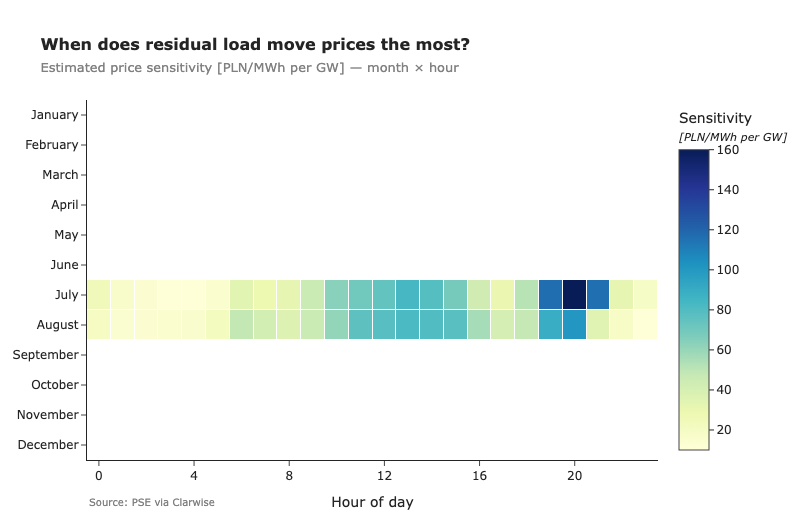

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
month,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,25.0,17.0,14.0,11.0,11.0,15.0,34.0,29.0,32.0,45.0,...,79.0,69.0,43.0,30.0,51.0,117.0,162.0,116.0,32.0,19.0
8,21.0,15.0,14.0,15.0,16.0,22.0,48.0,41.0,37.0,46.0,...,80.0,78.0,56.0,41.0,48.0,90.0,100.0,34.0,19.0,11.0
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
def cell_slope(group, xcol="residual_load_gw", ycol="rce", min_n=50):
    x = group[xcol].to_numpy(dtype=float)
    y = group[ycol].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < min_n:
        return np.nan
    lo, hi = np.quantile(x, [0.005, 0.995])
    m = (x >= lo) & (x <= hi)
    x, y = x[m], y[m]
    if len(x) < min_n or x.std() == 0:
        return np.nan
    slope, _intercept = np.polyfit(x, y, 1)
    return float(slope)


# Restrict to the period where the system is structurally comparable to today
# (matches the cutoff used in 04_residual_load_vs_price.py).
sens_cutoff = pd.Timestamp("2024-06-14", tz="UTC")
df_sens = df[df["interval_start_utc"] >= sens_cutoff]
print(
    f"Sensitivity surface fitted on {len(df_sens):,} hours "
    f'from {df_sens["interval_start_utc"].min().date()} '
    f'to {df_sens["interval_start_utc"].max().date()}.'
)

rows_ = []
for (m, h), g in df_sens.groupby(["month", "hour"]):
    rows_.append(
        {
            "month": int(m),
            "hour": int(h),
            "slope_pln_per_gw": cell_slope(g),
            "n": len(g),
            "mean_residual_gw": float(g["residual_load_gw"].mean()),
        }
    )
sens = pd.DataFrame(rows_).sort_values(["month", "hour"]).reset_index(drop=True)

month_names = [calendar.month_name[m] for m in range(1, 13)]
heat = sens.pivot(
    index="month", columns="hour", values="slope_pln_per_gw"
).reindex(index=range(1, 13), columns=range(0, 24))

fig3 = go.Figure(
    data=go.Heatmap(
        z=heat.values,
        x=list(heat.columns),
        y=[month_names[m - 1] for m in heat.index],
        colorscale="YlGnBu",
        zmin=10,
        zmax=160,
        colorbar=dict(
            title=(
                "Sensitivity<br>"
                "<span style='font-size:11px;font-style:italic'>[PLN/MWh per GW]</span>"
            ),
            ticks="outside",
        ),
        xgap=1,
        ygap=1,
    )
)
fig3.update_layout(
    title=dict(
        text=(
            "<span style='font-size:16px;font-weight:bold'>When does residual load move prices the most?</span>"
            "<br><span style='font-size:13px;color:gray'>Estimated price sensitivity [PLN/MWh per GW] — month × hour</span>"
        )
    ),
    template="simple_white",
    plot_bgcolor="#ffffff",
    paper_bgcolor="#ffffff",
    height=520,
    margin=dict(t=100, b=60, l=80, r=40),
)
fig3.update_xaxes(
    title="Hour of day",
    tickmode="array",
    tickvals=[0, 4, 8, 12, 16, 20],
    showgrid=False,
)
fig3.update_yaxes(autorange="reversed", showgrid=False)
fig3.add_annotation(
    text="Source: PSE via Clarwise",
    xref="paper",
    yref="paper",
    x=0.0,
    y=-0.14,
    xanchor="left",
    showarrow=False,
    font=dict(size=10, color="gray"),
)
fig3.show()

heat.round(0)

## Sensitivity table — key regimes

Pulls out the specific (month, hour) cells the blog quotes.


In [ ]:
def sens_at(month, hour):
    row = sens[(sens["month"] == month) & (sens["hour"] == hour)]
    if len(row) == 0:
        return np.nan
    return float(row["slope_pln_per_gw"].iloc[0])


regimes = pd.DataFrame(
    [
        ("Summer midday trough", 7, 12),
        ("Summer evening peak", 7, 19),
        ("Winter morning ramp", 1, 7),
        ("Winter evening peak", 1, 18),
        ("Summer night trough", 7, 3),
        ("Shoulder afternoon", 4, 15),
    ],
    columns=["regime", "month", "hour"],
)
regimes["sensitivity_pln_mwh_per_gw"] = regimes.apply(
    lambda r: sens_at(int(r["month"]), int(r["hour"])), axis=1
).round(0)
regimes

,regime,month,hour,sensitivity_pln_mwh_per_gw
0,Summer midday trough,7,12,75.0
1,Summer evening peak,7,19,117.0
2,Winter morning ramp,1,7,NaN
3,Winter evening peak,1,18,NaN
4,Summer night trough,7,3,11.0
5,Shoulder afternoon,4,15,NaN


## Marginal sensitivity by time-of-day band

Average sensitivity in the midday solar window (10–15), evening peak (17–21), and night
trough (00–05). Useful for the BESS-economics narrative.


In [ ]:
def band_mean(months, hours):
    sel = sens[sens["month"].isin(months) & sens["hour"].isin(hours)]
    return float(sel["slope_pln_per_gw"].mean())


all_months = list(range(1, 13))
summer_months = [6, 7, 8]
winter_months = [12, 1, 2]

bands = pd.DataFrame(
    [
        ("All year", "Midday (10–15)", band_mean(all_months, range(10, 16))),
        ("All year", "Evening (17–21)", band_mean(all_months, range(17, 22))),
        ("All year", "Night (00–05)", band_mean(all_months, range(0, 6))),
        ("Summer", "Midday (10–15)", band_mean(summer_months, range(10, 16))),
        ("Summer", "Evening (17–21)", band_mean(summer_months, range(17, 22))),
        ("Winter", "Evening (17–21)", band_mean(winter_months, range(17, 22))),
    ],
    columns=["season", "band", "avg_sensitivity_pln_per_gw"],
)
bands["avg_sensitivity_pln_per_gw"] = bands["avg_sensitivity_pln_per_gw"].round(
    0
)
bands

,season,band,avg_sensitivity_pln_per_gw
0,All year,Midday (10–15),75.0
1,All year,Evening (17–21),79.0
2,All year,Night (00–05),16.0
3,Summer,Midday (10–15),75.0
4,Summer,Evening (17–21),79.0
5,Winter,Evening (17–21),NaN


## Out-of-sample validation

Train the sensitivity surface on all-but-the-last available year, evaluate on the held-out
last year, and report the cell-wise correlation. Once 2020–2024 are loaded, this
corresponds to the train/test split discussed in the blog.


In [ ]:
if len(years_sorted) >= 2:
    train_years = years_sorted[:-1]
    test_year = years_sorted[-1]

    def surface(sub):
        rows__ = []
        for (m, h), g in sub.groupby(["month", "hour"]):
            rows__.append(
                {
                    "month": int(m),
                    "hour": int(h),
                    "slope": cell_slope(g, min_n=20),
                }
            )
        return pd.DataFrame(rows__)

    train_surf = surface(df[df["year"].isin(train_years)]).rename(
        columns={"slope": "train"}
    )
    test_surf = surface(df[df["year"] == test_year]).rename(
        columns={"slope": "test"}
    )
    merged = train_surf.merge(test_surf, on=["month", "hour"]).dropna()
    corr = float(merged["train"].corr(merged["test"]))
    print(f"Train years: {train_years}")
    print(f"Test year:   {test_year}")
    print(f"Cells compared: {len(merged)} / 288")
    print(f"Cell-wise correlation (train vs test slopes): {corr:.3f}")
    merged.head()
else:
    print("Need at least 2 years of data for out-of-sample validation.")

Train years: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
Test year:   2025
Cells compared: 192 / 288
Cell-wise correlation (train vs test slopes): -0.274


## BESS value concentration

Approximation: hourly arbitrage value ≈ |price − daily mean|. Compute what share of total
annual arbitrage value is concentrated in the most extreme hours of the year.


In [ ]:
df_arb = df.copy()
daily_mean = df_arb.groupby("date_local")["rce"].transform("mean")
df_arb["abs_spread"] = (df_arb["rce"] - daily_mean).abs()
total_value = float(df_arb["abs_spread"].sum())

rows__ = []
for top_pct in [1, 5, 10, 20, 50]:
    thr = df_arb["abs_spread"].quantile(1 - top_pct / 100.0)
    sub = df_arb[df_arb["abs_spread"] >= thr]
    rows__.append(
        {
            "top_pct_hours": top_pct,
            "share_of_total_value_pct": round(
                sub["abs_spread"].sum() / total_value * 100, 1
            ),
            "min_abs_spread_pln": round(float(thr), 1),
        }
    )
concentration = pd.DataFrame(rows__)
concentration

,top_pct_hours,share_of_total_value_pct,min_abs_spread_pln
0,1,8.8,571.5
1,5,25.7,318.2
2,10,39.7,222.4
3,20,58.5,144.8
4,50,87.4,54.3


## Blog FILL: cheat sheet

All the values to drop into the blog post, computed from whatever years are currently
loaded.


In [ ]:
print("=== TL;DR figures ===")
print(f"Overall R² (all years pooled):        {overall_r2*100:.0f}%")
print(
    f'Worst year R² ({int(worst_year_row["year"])}):                {worst_year_row["r2_lowess"]:.2f}'
)
print(
    f'Latest year R² ({int(latest_year_row["year"])}):               {latest_year_row["r2_lowess"]:.2f}'
)
print()
print("Sensitivity range (PLN/MWh per GW):")
print(
    f'  min cell: {sens["slope_pln_per_gw"].min():.0f}'
    f'  median: {sens["slope_pln_per_gw"].median():.0f}'
    f'  max cell: {sens["slope_pln_per_gw"].max():.0f}'
)
print()
print("Negative-price hours by year:")
for _, row in year_stats_df.iterrows():
    print(
        f'  {int(row["year"])}: {int(row["neg_price_hours"]):>4d} hours '
        f'({row["pct_hours_le_0"]:.2f}%)  median price {row["median_price_pln"]:.1f} PLN/MWh'
    )
print()
print("Seasonal residual-load range (P01–P99, GW):")
for s in ["Winter", "Summer"]:
    sub = df[df["season"] == s]
    print(
        f'  {s}: [{sub["residual_load_gw"].quantile(0.01):.1f}, '
        f'{sub["residual_load_gw"].quantile(0.99):.1f}]'
    )

=== TL;DR figures ===
Overall R² (all years pooled):        22%
Worst year R² (2022):                0.20
Latest year R² (2025):               0.54

Sensitivity range (PLN/MWh per GW):
  min cell: 11  median: 42  max cell: 162

Negative-price hours by year:
  2020:    0 hours (0.00%)  median price 204.9 PLN/MWh
  2021:    0 hours (0.00%)  median price 345.3 PLN/MWh
  2022:    0 hours (0.00%)  median price 699.9 PLN/MWh
  2023:   33 hours (0.38%)  median price 511.8 PLN/MWh
  2024:  204 hours (2.33%)  median price 396.6 PLN/MWh
  2025:  336 hours (5.45%)  median price 438.6 PLN/MWh

Seasonal residual-load range (P01–P99, GW):
  Winter: [9.5, 22.9]
  Summer: [7.5, 19.1]
